# Метод конечных элементов

In [73]:
import sys

sys.path.append('..')

### Пример №1

$y'' = -0.1y' - x$, $y(0) = 0$, $y(1) = 1$

##### Нахождение $y = y(x)$ методом конечных разностей

$\frac{y_{i+1} - 2y_i + y_{i-1}}{h^2} = -0.1\frac{y_{i+1} - y_{i-1}}{2h} - x_i$

$y_0 = 0$

$(1 + 0.05h)y_{i+1} - 2y_i + (1 - 0.05h)y_{i-1} = -x_ih^2, 1 \leq i \leq n-2$

$y_{n-1} = 1$

In [74]:
import numpy as np
from modules.slae.solver.direct.lu_decomposition import lu_3_diag_decomposition, lu_3_diag_solve

a = 0
b = 1.
N = [5, 25, 125]

x = [np.linspace(a, b, n) for n in N]
y_fd = []

for i in range(len(N)):
    n = N[i]
    h = x[i][1] - x[i][0]

    d = -2*np.ones(n)
    c = (1 - 0.05*h)*np.ones(n - 1)
    e = (1 + 0.05*h)*np.ones(n - 1)

    d[0] = 1.
    d[n-1] = 1.

    e[0] = 0.
    c[n-2] = 0.

    b = -x[i]*h*h

    b[0] = 0.
    b[n-1] = 1.

    ct, dt, et = lu_3_diag_decomposition(c, d, e)     

    y_fd.append(lu_3_diag_solve(ct, dt, et, b))

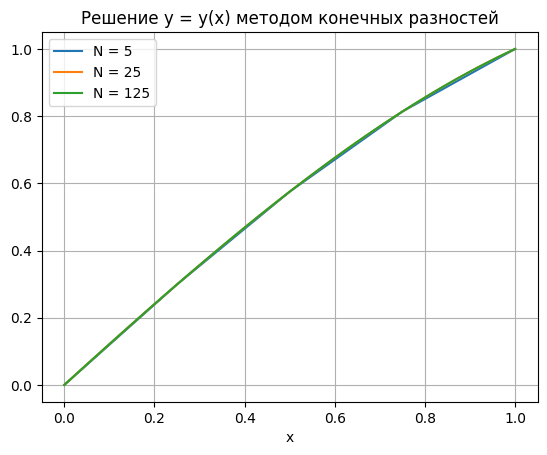

In [75]:
import matplotlib.pyplot as plt

for i in range(len(N)):
    plt.plot(x[i], y_fd[i], label=f'N = {N[i]}')

plt.title("Решение y = y(x) методом конечных разностей")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $y = y(x)$ методом конечных элементов

$y'' = -0.1y' - x \Rightarrow -y'' - 0.1y' = x \Rightarrow a = 1, b = -0.1, c = 0, g = x$ 

$\psi_1 = \frac{s_2 - x}{h}, \psi_2 = \frac{x - s_1}{h}, h = s_2 - s_1$

$$K \cdot \alpha = G$$

$K_{i,j}^e = \int_{s1}^{s2} [\psi_i'\psi_j' - 0.1\psi_i\psi_j']dx, \psi_1' = -\frac{1}{h}, \psi_2' = \frac{1}{h}$

$K_{1,1}^e = \int_{s1}^{s2} [\frac{1}{h^2} + 0.1\frac{s_2 - x}{h^2}]dx = \frac{1}{h} + 0.05$

$K_{1,2}^e = \int_{s1}^{s2} [-\frac{1}{h^2} - 0.1\frac{s_2 - x}{h^2}]dx = -\frac{1}{h} - 0.05$

$K_{2,1}^e = \int_{s1}^{s2} [-\frac{1}{h^2} + 0.1\frac{x - s_1}{h^2}]dx = -\frac{1}{h} + 0.05$

$K_{2,2}^e = \int_{s1}^{s2} [\frac{1}{h^2} - 0.1\frac{x - s_1}{h^2}]dx = \frac{1}{h} - 0.05$

$
K = \begin{pmatrix}
    \frac{1}{h} + 0.05 & -\frac{1}{h} - 0.05 & 0 & ... & 0 \\
    -\frac{1}{h} + 0.05 & 2\frac{1}{h} & -\frac{1}{h} - 0.05 & ... & 0 \\
    ... & ... & ... & ... & ... \\ 
    0 & ... & -\frac{1}{h} + 0.05 & 2\frac{1}{h} & -\frac{1}{h} - 0.05 \\ 
    0 & ... & 0 & -\frac{1}{h} + 0.05 & \frac{1}{h} - 0.05  
\end{pmatrix}
$

$g_1^e = \int_{s1}^{s2} x\frac{s_2 - x}{h}dx = \frac{h}{6}[s_2 + 2s_1]$

$g_2^e = \int_{s1}^{s2} x\frac{x - s_1}{h}dx = \frac{h}{6}[2s_2 + s_1]$

$
G = \begin{pmatrix}
    \frac{h}{6}[s_2^0 + 2s_1^0] - y_0' \\
    \frac{h}{6}[2s_2^0 + s_1^0 + s_2^1 + 2s_1^1] \\
    ... \\ 
    \frac{h}{6}[2s_2^{n-3} + s_1^{n-3} + s_2^{n-2} + 2s_1^{n-2}] \\ 
    \frac{h}{6}[2s_2^{n-2} + s_1^{n-2}] + y_{n-1}'  
\end{pmatrix} = 
\begin{pmatrix}
    \frac{h}{6}[3x_0 + h] - y_0' \\
    hx_1 \\
    ... \\ 
    hx_{n-2} \\ 
    \frac{h}{6}[3x_{n-1} - h] + y_{n-1}'  
\end{pmatrix}
$

##### Для граничных условий $y(0) = 0$, $y(1) = 1$

$
K = \begin{pmatrix}
    2\frac{1}{h} & -\frac{1}{h} - 0.05 & 0 & ... \\
    -\frac{1}{h} + 0.05 & 2\frac{1}{h} & -\frac{1}{h} - 0.05 & ... \\
    ... & ... & ... & ... \\ 
    0 & ... & -\frac{1}{h} + 0.05 & 2\frac{1}{h}  
\end{pmatrix}
$

$
G = \begin{pmatrix}
    hx_1 \\
    ... \\ 
    hx_{n-2} + \frac{1}{h} + 0.05 \\   
\end{pmatrix}
$

In [76]:
y_fe = []

for i in range(len(N)):
    n = N[i]
    h = x[i][1] - x[i][0]

    d = 2*np.ones(n-2)/h
    c = (-1/h + 0.05)*np.ones(n - 3)
    e = (-1/h - 0.05)*np.ones(n - 3)

    b = h*x[i]

    b[0] = 0.
    b[n-2] += 1/h + 0.05
    b[n-1] = 1.

    ct, dt, et = lu_3_diag_decomposition(c, d, e)     

    lu_3_diag_solve(ct, dt, et, b[1:n-1])

    y_fe.append(b)

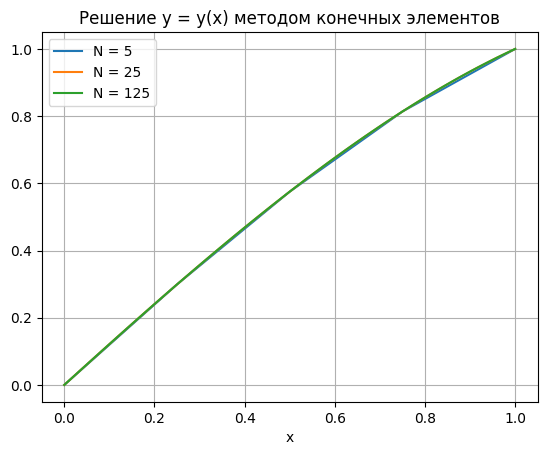

In [77]:
for i in range(len(N)):
    plt.plot(x[i], y_fe[i], label=f'N = {N[i]}')

plt.title("Решение y = y(x) методом конечных элементов")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Сравнение решении y = y(x)

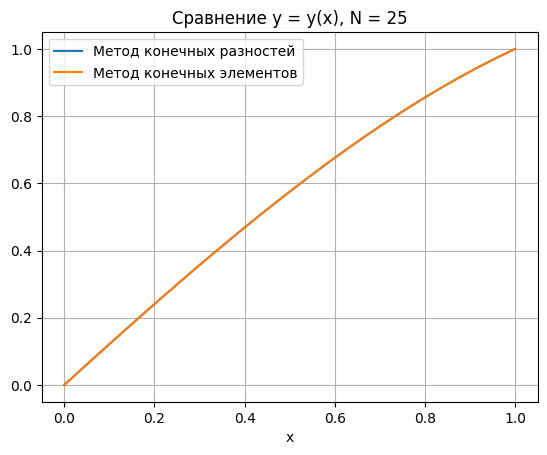

In [78]:
plt.plot(x[1], y_fd[1], label='Метод конечных разностей')
plt.plot(x[1], y_fe[1], label='Метод конечных элементов')

plt.title(f"Сравнение y = y(x), N = {N[1]}")
plt.xlabel('x')
plt.grid()
plt.legend()

### Пример №2

$y'' = -0.1y' - x$, $y(0) = 0$, $y'(1) = 1$

##### Нахождение $y = y(x)$ методом конечных разностей

$\frac{y_{i+1} - 2y_i + y_{i-1}}{h^2} = -0.1\frac{y_{i+1} - y_{i-1}}{2h} - x_i$

$y_0 = 0$

$(1 + 0.05h)y_{i+1} - 2y_i + (1 - 0.05h)y_{i-1} = -x_ih^2, 1 \leq i \leq n-2$

$\frac{y_n - y_{n-2}}{2h} = 1 \Rightarrow y_n = 2h + y_{n-2}$

$(1 + 0.05h)y_n - 2y_{n-1} + (1 - 0.05h)y_{n-2} = -x_{n-1}h^2 \Rightarrow -2y_{n-1} + 2y_{n-2} = -x_{n-1}h^2 - 2h(1 + 0.05h)$

In [79]:
y_fd = []

for i in range(len(N)):
    n = N[i]
    h = x[i][1] - x[i][0]

    d = -2*np.ones(n)
    c = (1 - 0.05*h)*np.ones(n - 1)
    e = (1 + 0.05*h)*np.ones(n - 1)

    d[0] = 1.

    e[0] = 0.
    c[n-2] = 2.

    b = -x[i]*h*h

    b[0] = 0.
    b[n-1] -= 2*h*(1 + 0.05*h)

    ct, dt, et = lu_3_diag_decomposition(c, d, e)     

    y_fd.append(lu_3_diag_solve(ct, dt, et, b))

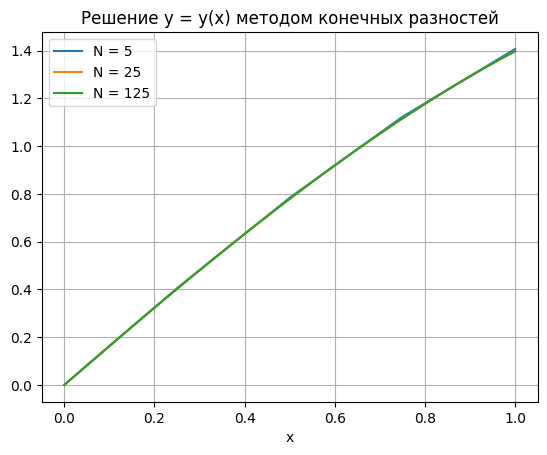

In [80]:
for i in range(len(N)):
    plt.plot(x[i], y_fd[i], label=f'N = {N[i]}')

plt.title("Решение y = y(x) методом конечных разностей")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $y = y(x)$ методом конечных элементов

$$K \cdot \alpha = G$$

$
K = \begin{pmatrix}
    \frac{1}{h} + 0.05 & -\frac{1}{h} - 0.05 & 0 & ... & 0 \\
    -\frac{1}{h} + 0.05 & 2\frac{1}{h} & -\frac{1}{h} - 0.05 & ... & 0 \\
    ... & ... & ... & ... & ... \\ 
    0 & ... & -\frac{1}{h} + 0.05 & 2\frac{1}{h} & -\frac{1}{h} - 0.05 \\ 
    0 & ... & 0 & -\frac{1}{h} + 0.05 & \frac{1}{h} - 0.05  
\end{pmatrix}
$

$
G = \begin{pmatrix}
    \frac{h}{6}[s_2^0 + 2s_1^0] - y_0' \\
    \frac{h}{6}[2s_2^0 + s_1^0 + s_2^1 + 2s_1^1] \\
    ... \\ 
    \frac{h}{6}[2s_2^{n-3} + s_1^{n-3} + s_2^{n-2} + 2s_1^{n-2}] \\ 
    \frac{h}{6}[2s_2^{n-2} + s_1^{n-2}] + y_{n-1}'  
\end{pmatrix} = 
\begin{pmatrix}
    \frac{h}{6}[3x_0 + h] - y_0' \\
    hx_1 \\
    ... \\ 
    hx_{n-2} \\ 
    \frac{h}{6}[3x_{n-1} - h] + y_{n-1}'  
\end{pmatrix}
$

##### Для граничных условий $y(0) = 0$, $y'(1) = 1$

$
K = \begin{pmatrix}    
    2\frac{1}{h} & -\frac{1}{h} - 0.05 & ... & 0 \\
    ... & ... & ... & ... \\ 
    ... & -\frac{1}{h} + 0.05 & 2\frac{1}{h} & -\frac{1}{h} - 0.05 \\ 
    ... & 0 & -\frac{1}{h} + 0.05 & \frac{1}{h} - 0.05  
\end{pmatrix}
$

$
G = \begin{pmatrix}    
    hx_1 \\
    ... \\ 
    hx_{n-2} \\ 
    \frac{h}{6}[3x_{n-1} - h] + y_{n-1}'  
\end{pmatrix} = 
\begin{pmatrix}    
    hx_1 \\
    ... \\ 
    hx_{n-2} \\ 
    \frac{h}{6}[3x_{n-1} - h] + 1  
\end{pmatrix}
$

In [81]:
y_fe = []

for i in range(len(N)):
    n = N[i]
    h = x[i][1] - x[i][0]

    d = 2*np.ones(n-1)/h
    c = (-1/h + 0.05)*np.ones(n - 2)
    e = (-1/h - 0.05)*np.ones(n - 2)

    b = h*x[i]

    d[n-2] = 1./h - 0.05

    b[0] = 0.
    b[n-1] = h*(3*x[i][n-1] - h)/6 + 1.

    ct, dt, et = lu_3_diag_decomposition(c, d, e)     

    lu_3_diag_solve(ct, dt, et, b[1:n])

    y_fe.append(b)

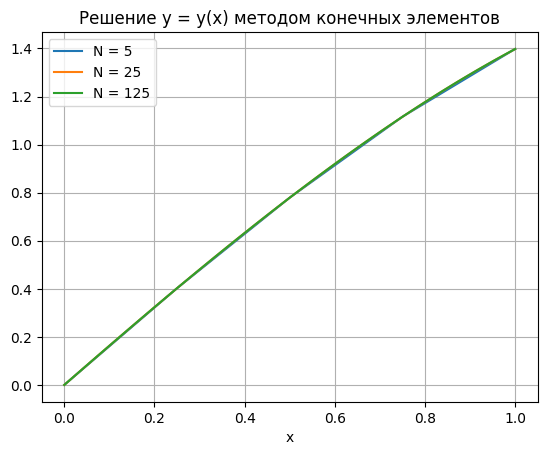

In [82]:
for i in range(len(N)):
    plt.plot(x[i], y_fe[i], label=f'N = {N[i]}')

plt.title("Решение y = y(x) методом конечных элементов")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Сравнение решении y = y(x)

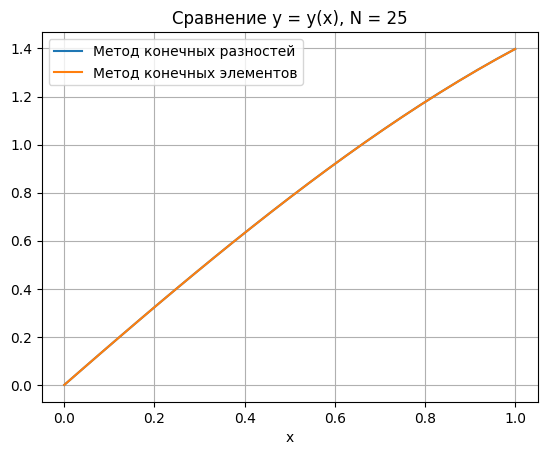

In [83]:
plt.plot(x[1], y_fd[1], label='Метод конечных разностей')
plt.plot(x[1], y_fe[1], label='Метод конечных элементов')

plt.title(f"Сравнение y = y(x), N = {N[1]}")
plt.xlabel('x')
plt.grid()
plt.legend()